# Step 4: XGBoost Model Training
Train and evaluate XGBoost classifier with hyperparameter tuning

In [1]:
# Install dependencies if needed:
# pip install xgboost scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
# Load feature-engineered data
df = pd.read_csv('../data/processed/bank_churn_features.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (10000, 15)
Columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'BalanceSalaryRatio', 'TenureAgeRatio', 'ProductsPerTenure', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [3]:
# Prepare features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (10000, 14)
Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 14)
Test set: (2000, 14)


In [5]:
# Hyperparameter tuning with GridSearchCV
params = {
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

print("Starting hyperparameter tuning...")
grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    params,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.4f}")

Starting hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\Kisho\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\Kisho\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\Kisho\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation score: 0.8630


In [6]:
# Get best model and make predictions
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Accuracy: {accuracy:.2%}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 86.75%
ROC AUC Score: 0.8673

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.81      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



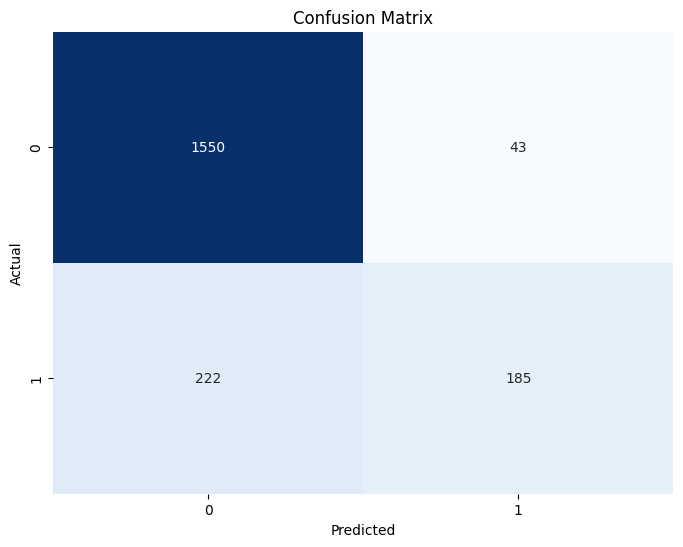

In [7]:
# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

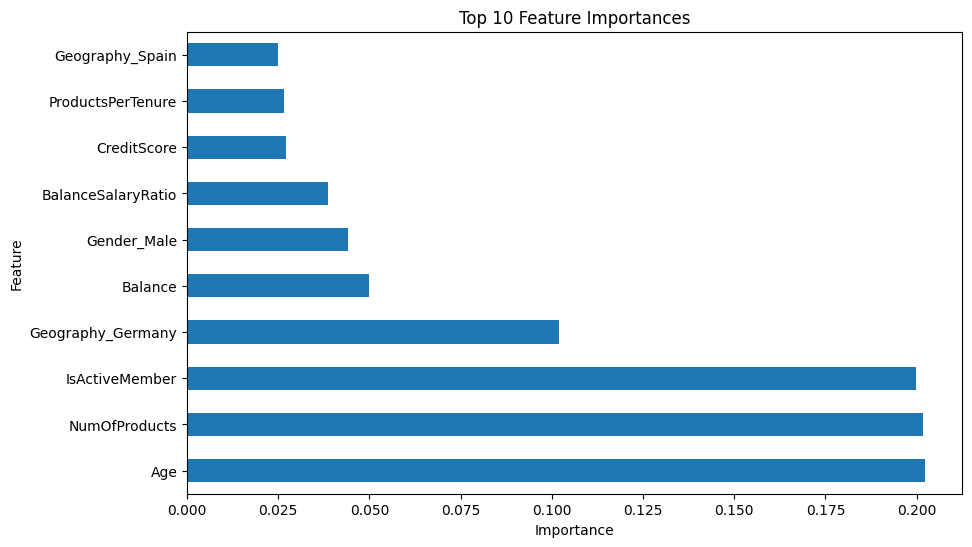


Top 10 Features:
Age                   0.202311
NumOfProducts         0.201624
IsActiveMember        0.199783
Geography_Germany     0.101990
Balance               0.049822
Gender_Male           0.044065
BalanceSalaryRatio    0.038653
CreditScore           0.026999
ProductsPerTenure     0.026637
Geography_Spain       0.024850
dtype: float32


In [8]:
# Feature importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = feat_imp.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(top_features)

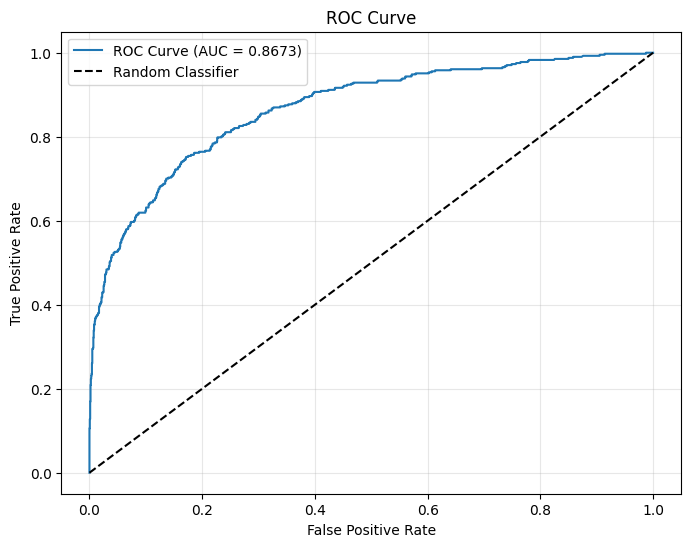

In [9]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../outputs/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Save model results
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_pred_proba
})

results_df.to_csv('../outputs/model_results.csv', index=False)
print("Model results saved to outputs/model_results.csv")

Model results saved to outputs/model_results.csv
